# VSL400 – Vietnamese Sign Language Dataset
Notebook để khám phá và load dataset VSL400 trên Kaggle / Google Colab.

**DOI:** https://doi.org/10.5281/zenodo.17943574

In [1]:
import os
print(os.listdir('/kaggle/input/datasets/bowboochua9/vsl400'))

['Part_4', 'Part_7', 'Part_6', 'Part_1', 'Part_5', 'Part_2', 'Part_3']


## 1. Setup – Xác định môi trường & mount drive (nếu Colab)

In [2]:
import os, json, sys
from pathlib import Path
from collections import Counter

# Detect environment
IS_KAGGLE = 'KAGGLE_URL_BASE' in os.environ
IS_COLAB  = 'google.colab' in sys.modules
print('Kaggle:', IS_KAGGLE, '| Colab:', IS_COLAB)

# ---- Google Colab: mount Google Drive ----
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Thay đường dẫn cho đúng với Drive của bạn
    DATASET_ROOT = Path('/content/drive/MyDrive/vsl400_blurred_splits')

# ---- Kaggle: dataset đã được add vào notebook ----
elif IS_KAGGLE:
    # Sau khi add dataset vào notebook, thay slug cho đúng
    DATASET_ROOT = Path('/kaggle/input/datasets/bowboochua9/vsl400')

# ---- Local fallback ----
else:
    DATASET_ROOT = Path('./vsl400_blurred_splits')

print('Dataset root:', DATASET_ROOT)
print('Exists:', DATASET_ROOT.exists())

Kaggle: True | Colab: False
Dataset root: /kaggle/input/datasets/bowboochua9/vsl400
Exists: True


## 2. Load metadata từ tất cả splits

In [3]:
VIEWS = ['front_view', 'left_view', 'right_view']
NUM_SPLITS = 7

all_metadata = {v: [] for v in VIEWS}

for split_idx in range(1, NUM_SPLITS + 1):
    # ĐÃ SỬA CHÍNH XÁC ĐƯỜNG DẪN LỒNG NHAU Ở ĐÂY
    split_dir = DATASET_ROOT / f'Part_{split_idx}' / f'split_{split_idx}'
    
    if not split_dir.exists():
        print(f'[WARN] {split_dir} not found, skipping')
        continue
    for view in VIEWS:
        json_path = split_dir / f'{view}.json'
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        all_metadata[view].extend(data)
    print(f'Part {split_idx}: loaded {len(data)} entries per view')

print(f'\nTổng entries (front_view): {len(all_metadata["front_view"])}')

Part 1: loaded 3537 entries per view
Part 2: loaded 3536 entries per view
Part 3: loaded 3536 entries per view
Part 4: loaded 3536 entries per view
Part 5: loaded 3536 entries per view
Part 6: loaded 3536 entries per view
Part 7: loaded 3536 entries per view

Tổng entries (front_view): 24753


## 3. Thống kê cơ bản

In [4]:
import pandas as pd

df = pd.DataFrame(all_metadata['front_view'])
print('=== DataFrame Info ===')
print(df.dtypes)
print(f'\nShape: {df.shape}')
df.head()

=== DataFrame Info ===
video_id           object
signer_id          object
fps               float64
resolution          int64
gloss              object
num_frames          int64
length_seconds    float64
dtype: object

Shape: (24753, 7)


,video_id,signer_id,fps,resolution,gloss,num_frames,length_seconds
0,000000,001,25.0,1080,Anh,65,2.60
1,000001,001,25.0,1080,Anh,56,2.24
2,000002,001,25.0,1080,Chị,62,2.48
3,000003,001,25.0,1080,Chị,76,3.04
4,000004,001,25.0,1080,Em,65,2.60


In [5]:
print('=== Thống kê Dataset ===')
print(f'Tổng video (1 view):   {len(df):,}')
print(f'Tổng video (3 views):  {len(df)*3:,}')
print(f'Số lượng gloss (từ):   {df["gloss"].nunique()}')
print(f'Số lượng signer:       {df["signer_id"].nunique()}')
print(f'\nPhân phối số frame:')
print(df['num_frames'].describe())
print(f'\nPhân phối thời lượng (giây):')
print(df['length_seconds'].describe())

=== Thống kê Dataset ===
Tổng video (1 view):   24,753
Tổng video (3 views):  74,259
Số lượng gloss (từ):   400
Số lượng signer:       26

Phân phối số frame:
count    24753.000000
mean        64.124833
std         10.274254
min         34.000000
25%         57.000000
50%         63.000000
75%         70.000000
max        143.000000
Name: num_frames, dtype: float64

Phân phối thời lượng (giây):
count    24753.000000
mean         2.564993
std          0.410970
min          1.360000
25%          2.280000
50%          2.520000
75%          2.800000
max          5.720000
Name: length_seconds, dtype: float64


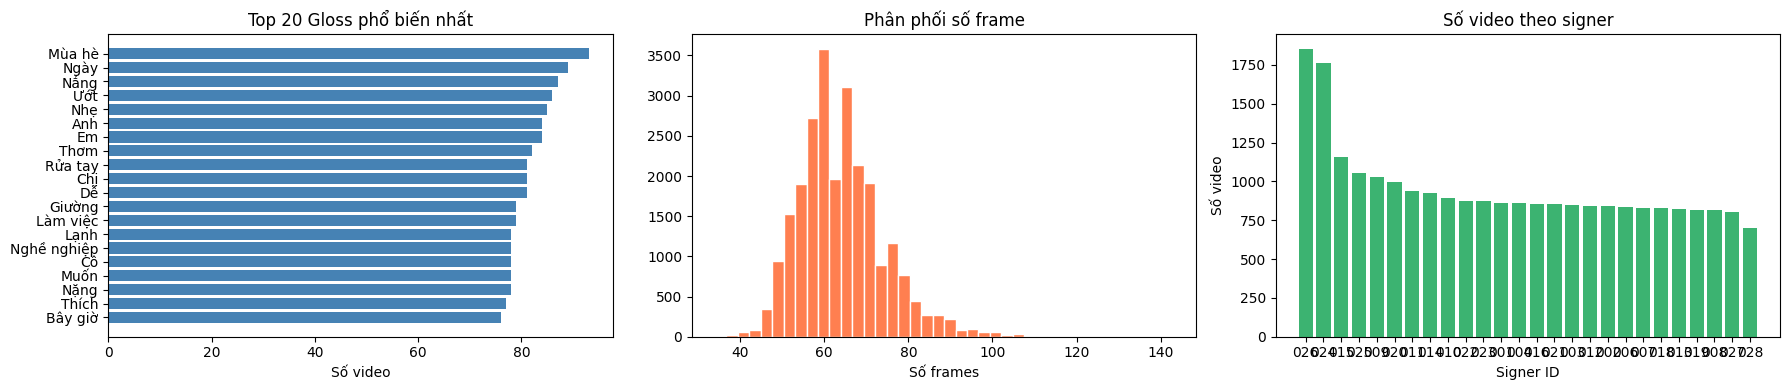

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Top 20 gloss phổ biến nhất
top_gloss = df['gloss'].value_counts().head(20)
axes[0].barh(top_gloss.index[::-1], top_gloss.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Gloss phổ biến nhất')
axes[0].set_xlabel('Số video')

# Phân phối num_frames
axes[1].hist(df['num_frames'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Phân phối số frame')
axes[1].set_xlabel('Số frames')

# Video per signer
signer_counts = df['signer_id'].value_counts()
axes[2].bar(signer_counts.index, signer_counts.values, color='mediumseagreen')
axes[2].set_title('Số video theo signer')
axes[2].set_xlabel('Signer ID')
axes[2].set_ylabel('Số video')

plt.tight_layout()
plt.show()

## 4. Train / Val / Test Split

Splits 1-5 → Train | Split 6 → Val | Split 7 → Test

(Chiến lược phổ biến, bạn có thể thay đổi theo nhu cầu)

In [7]:
def load_splits(split_indices, view='front_view'):
    records = []
    for idx in split_indices:
        # ĐÃ SỬA CHÍNH XÁC ĐƯỜNG DẪN LỒNG NHAU Ở ĐÂY
        split_dir = DATASET_ROOT / f'Part_{idx}' / f'split_{idx}'
        
        with open(split_dir / f'{view}.json', 'r', encoding='utf-8') as f:
            data = json.load(f)
        for item in data:
            item['video_path'] = str(split_dir / view / f"{item['video_id']}.mp4")
            item['split'] = idx
        records.extend(data)
    return pd.DataFrame(records)

VIEW = 'front_view'   # hoặc 'left_view' / 'right_view'

df_train = load_splits([1, 2, 3, 4, 5], view=VIEW)
df_val   = load_splits([6], view=VIEW)
df_test  = load_splits([7], view=VIEW)

print(f'Train: {len(df_train):,} videos')
print(f'Val:   {len(df_val):,} videos')
print(f'Test:  {len(df_test):,} videos')
df_train.head()

Train: 17,681 videos
Val:   3,536 videos
Test:  3,536 videos


,video_id,signer_id,fps,resolution,gloss,num_frames,length_seconds,video_path,split
0,000000,001,25.0,1080,Anh,65,2.60,/kaggle/input/datasets/bowboochua9/vsl400/Part...,1
1,000001,001,25.0,1080,Anh,56,2.24,/kaggle/input/datasets/bowboochua9/vsl400/Part...,1
2,000002,001,25.0,1080,Chị,62,2.48,/kaggle/input/datasets/bowboochua9/vsl400/Part...,1
3,000003,001,25.0,1080,Chị,76,3.04,/kaggle/input/datasets/bowboochua9/vsl400/Part...,1
4,000004,001,25.0,1080,Em,65,2.60,/kaggle/input/datasets/bowboochua9/vsl400/Part...,1


## 5. Tạo Label Encoder cho gloss

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['gloss'])

df_train['label'] = le.transform(df_train['gloss'])
df_val['label']   = le.transform(df_val['gloss'])
df_test['label']  = le.transform(df_test['gloss'])

NUM_CLASSES = len(le.classes_)
print(f'Số lớp (gloss): {NUM_CLASSES}')
print('Ví dụ mapping:')
for i, cls in enumerate(le.classes_[:10]):
    print(f'  {i:3d} → {cls}')

Số lớp (gloss): 400
Ví dụ mapping:
    0 → Anh
    1 → Ba lô
    2 → Bia
    3 → Buổi chiều
    4 → Buổi sáng
    5 → Buổi trưa
    6 → Buổi tối
    7 → Bà ngoại
    8 → Bà nội
    9 → Bàn phím


## 6. Đọc và preview một video

Video ID: 000000 | Gloss: Anh | Signer: 001


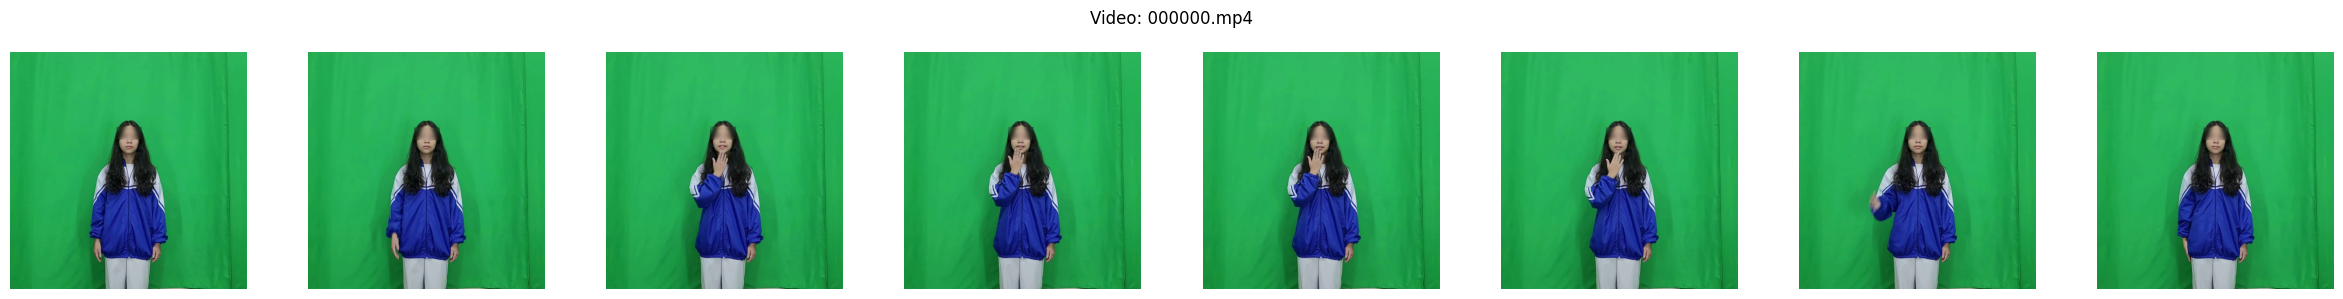

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def preview_video(video_path, num_frames=8):
    """Hiển thị một số frame từ video."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, num_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 3))
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis('off')
    plt.suptitle(f'Video: {Path(video_path).name}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Preview video đầu tiên trong train set
sample = df_train.iloc[0]
print(f'Video ID: {sample["video_id"]} | Gloss: {sample["gloss"]} | Signer: {sample["signer_id"]}')
preview_video(sample['video_path'])

## 7. PyTorch Dataset class (dùng cho training)

In [10]:
# Cài thêm nếu cần
# !pip install torch torchvision -q

import torch
from torch.utils.data import Dataset, DataLoader

class VSL400Dataset(Dataset):
    """
    PyTorch Dataset cho VSL400.
    Trả về tensor frames (T, C, H, W) và label.
    """
    def __init__(self, df, num_frames=16, img_size=224, transform=None):
        self.df = df.reset_index(drop=True)
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_video(self, path):
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, max(total - 1, 0), self.num_frames, dtype=int)
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
                frames.append(frame)
            else:
                frames.append(np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        cap.release()
        return np.stack(frames)  # (T, H, W, C)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._load_video(row['video_path'])   # (T, H, W, C)
        frames = torch.tensor(frames, dtype=torch.float32) / 255.0
        frames = frames.permute(0, 3, 1, 2)            # (T, C, H, W)
        if self.transform:
            frames = torch.stack([self.transform(f) for f in frames])
        label = int(row['label'])
        return frames, label

# Test nhanh
ds_train = VSL400Dataset(df_train, num_frames=16, img_size=224)
print(f'Train dataset size: {len(ds_train)}')
frames, label = ds_train[0]
print(f'Frame tensor shape: {frames.shape}')  # (16, 3, 224, 224)
print(f'Label: {label} → {le.classes_[label]}')

Train dataset size: 17681
Frame tensor shape: torch.Size([16, 3, 224, 224])
Label: 0 → Anh


In [11]:
# DataLoaders
BATCH_SIZE = 4  # Giảm nếu OOM
NUM_WORKERS = 2

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)

ds_val  = VSL400Dataset(df_val, num_frames=16, img_size=224)
ds_test = VSL400Dataset(df_test, num_frames=16, img_size=224)

val_loader  = DataLoader(ds_val,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Kiểm tra 1 batch
batch_frames, batch_labels = next(iter(train_loader))
print('Batch frames shape:', batch_frames.shape)  # (B, T, C, H, W)
print('Batch labels:', batch_labels)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch frames shape: torch.Size([4, 16, 3, 224, 224])
Batch labels: tensor([292, 318, 149, 258])


## 8. Kiểm tra đồng bộ 3 views (sanity check)

In [12]:
# Kiểm tra video_id khớp nhau giữa 3 views trong cùng split
for split_idx in range(1, NUM_SPLITS + 1):
    # ĐÃ SỬA LẠI ĐƯỜNG DẪN Ở DÒNG DƯỚI ĐÂY:
    split_dir = DATASET_ROOT / f'Part_{split_idx}' / f'split_{split_idx}'
    
    ids = {}
    for view in VIEWS:
        with open(split_dir / f'{view}.json', 'r', encoding='utf-8') as f:
            data = json.load(f)
        ids[view] = set(item['video_id'] for item in data)

    front_ids = ids['front_view']
    left_ids  = ids['left_view']
    right_ids = ids['right_view']

    ok = (front_ids == left_ids == right_ids)
    print(f'Part {split_idx}: {len(front_ids)} IDs | Synchronized: {"✅" if ok else "❌"}')

Part 1: 3537 IDs | Synchronized: ✅
Part 2: 3536 IDs | Synchronized: ✅
Part 3: 3536 IDs | Synchronized: ✅
Part 4: 3536 IDs | Synchronized: ✅
Part 5: 3536 IDs | Synchronized: ✅
Part 6: 3536 IDs | Synchronized: ✅
Part 7: 3536 IDs | Synchronized: ✅
